# Modelling depression severity: a PHQ-9 case study

**An introduction to statistical modelling in medical contexts**

## Learning objectives

By the end of this notebook you should be able to:

1. Fit and interpret a **simple linear regression** with a quantitative predictor.
2. Include **qualitative (categorical) predictors** via dummy variables and interpret coefficients relative to a reference category.
3. Build a **multiple regression** combining quantitative and qualitative factors, and interpret each coefficient as an *adjusted* effect ("holding the other variables fixed").
4. Detect lack of fit with **residual plots** and correct it with basic **non-linear forms**: a quadratic term and a log transformation.
5. Compare models using $R^2$, adjusted $R^2$ and AIC.

## Clinical background: the PHQ-9

The **Patient Health Questionnaire-9 (PHQ-9)** is one of the most widely used screening instruments for depression in primary care. Patients rate how often, over the last two weeks, they have been bothered by each of 9 symptoms (0 = not at all … 3 = nearly every day). The total score ranges **0–27**:

| Score | Interpretation |
|---|---|
| 0–4 | Minimal |
| 5–9 | Mild |
| 10–14 | Moderate |
| 15–19 | Moderately severe |
| 20–27 | Severe |

> **A modelling caveat before we start.** The PHQ-9 total is a *bounded, integer-valued* score, not a truly continuous measurement. Treating it as a continuous response in a linear model is a common and reasonable approximation for teaching (and often in practice), but keep the limitation in mind — we return to it at the end.

## The (simulated) study

We use simulated data for **240 primary-care patients** in a study of lifestyle and treatment factors associated with depression severity. Patients were randomized to no treatment, psychotherapy, or antidepressant medication 8 weeks before assessment.

| Variable | Type | Description |
|---|---|---|
| `phq9` | quantitative (response) | PHQ-9 total score, 0–27 |
| `age` | quantitative | years |
| `sleep_hours` | quantitative | average nightly sleep |
| `exercise_hours` | quantitative | hours of exercise per week |
| `sex` | qualitative (2 levels) | Female / Male |
| `treatment` | qualitative (3 levels) | none / therapy / medication |

*Because the data are simulated, we know the true data-generating process — a luxury we never have in real research, but ideal for checking whether our models recover the truth.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook")
df = pd.read_csv("https://raw.githubusercontent.com/thousandoaks/Maths4DS-II/refs/heads/main/phq9_study.csv")
df.head()

,patient_id,phq9,age,sleep_hours,exercise_hours,sex,treatment
0,1,14,23,9.2,1.2,Female,therapy
1,2,6,65,6.7,1.7,Male,none
2,3,6,58,5.6,0.5,Female,medication
3,4,1,45,7.3,0.5,Male,medication
4,5,1,44,7.3,7.8,Female,medication


## 1. Exploring the data

Always look before you model. We check distributions and the marginal relationship of each candidate predictor with the response.

In [2]:
df.describe().round(2)

,patient_id,phq9,age,sleep_hours,exercise_hours
count,240.00,240.00,240.00,240.00,240.00
mean,120.50,6.47,49.14,7.03,2.70
std,69.43,4.23,16.89,1.41,2.64
min,1.00,0.00,18.00,3.50,0.00
25%,60.75,3.00,35.00,6.00,0.80
50%,120.50,6.00,48.50,7.00,1.80
75%,180.25,9.00,64.25,7.90,3.70
max,240.00,20.00,79.00,10.50,12.00


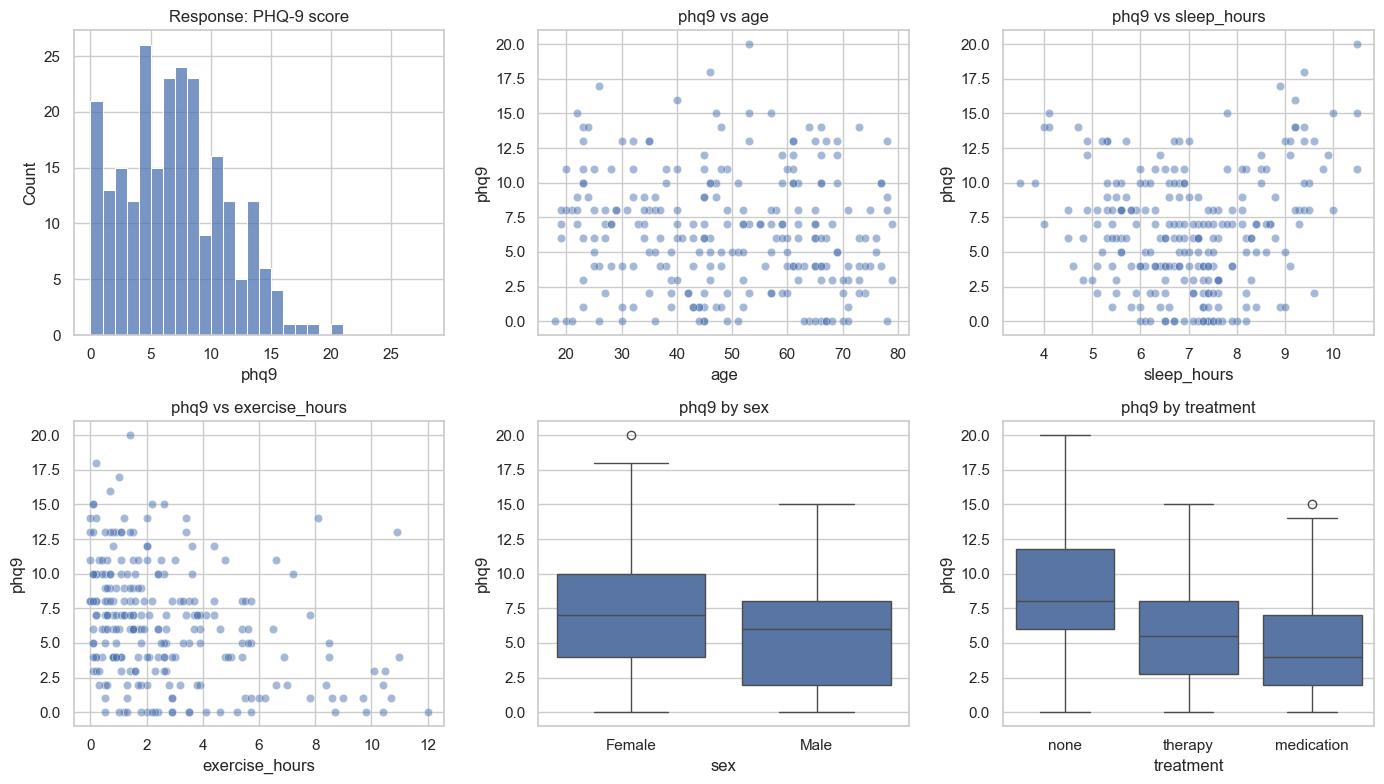

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

sns.histplot(df["phq9"], bins=range(0, 29), ax=axes[0, 0])
axes[0, 0].set_title("Response: PHQ-9 score")

for ax, var in zip(axes.flat[1:4], ["age", "sleep_hours", "exercise_hours"]):
    sns.scatterplot(data=df, x=var, y="phq9", alpha=0.5, ax=ax)
    ax.set_title(f"phq9 vs {var}")

sns.boxplot(data=df, x="sex", y="phq9", ax=axes[1, 1])
axes[1, 1].set_title("phq9 by sex")
sns.boxplot(data=df, x="treatment", y="phq9",
            order=["none", "therapy", "medication"], ax=axes[1, 2])
axes[1, 2].set_title("phq9 by treatment")
plt.tight_layout()

**What do you see?**

- `exercise_hours`: scores fall as exercise increases, but the decline seems to *flatten out* — the difference between 0 and 2 hours looks bigger than between 8 and 10.
- `sleep_hours`: not a straight line at all — scores are high for *short* sleepers, lowest around 7–8 h, and rise again for long sleepers. A **U-shape**.
- `age`: a weak, roughly linear downward drift, if anything.
- Both boxplots suggest group differences: females slightly higher; treated groups lower.

We will start simple anyway — deliberately mis-specifying the model at first — and let the diagnostics tell us what to fix.

## 2. Simple linear regression: one quantitative predictor

$$\text{phq9}_i = \beta_0 + \beta_1\,\text{exercise}_i + \varepsilon_i,\qquad \varepsilon_i \sim N(0,\sigma^2)$$

- $\beta_0$ (intercept): the **expected PHQ-9 score of a patient who does no exercise**.
- $\beta_1$ (slope): the **expected change in PHQ-9 per additional weekly hour of exercise**.

We fit by ordinary least squares using statsmodels' formula interface (R-style formulas).

In [4]:
m1 = smf.ols("phq9 ~ exercise_hours", data=df).fit()
print(m1.summary().tables[1])
print(f"R-squared: {m1.rsquared:.3f}")

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          7.8984      0.370     21.361      0.000       7.170       8.627
exercise_hours    -0.5310      0.098     -5.415      0.000      -0.724      -0.338
R-squared: 0.110


**Reading the output.** Each additional hour of weekly exercise is associated with a decrease of about |slope| points on the PHQ-9 (check the sign and value in your output). The p-value tests $H_0:\beta_1=0$; the confidence interval gives the plausible range. $R^2$ is the fraction of variance in PHQ-9 scores explained — modest, as expected: depression severity depends on much more than exercise.

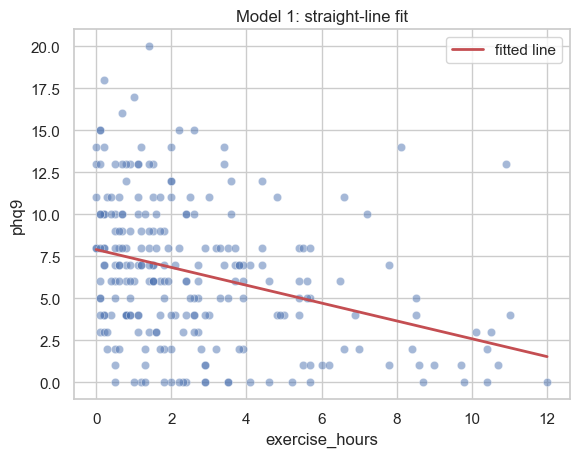

In [5]:
ax = sns.scatterplot(data=df, x="exercise_hours", y="phq9", alpha=0.5)
xg = np.linspace(0, df.exercise_hours.max(), 100)
ax.plot(xg, m1.predict(pd.DataFrame({"exercise_hours": xg})), "r-", lw=2, label="fitted line")
ax.legend(); ax.set_title("Model 1: straight-line fit")
plt.show()

## 3. Qualitative predictors: dummy variables

Categorical factors enter a regression as **dummy (indicator) variables**. For `sex` with two levels:

$$\text{phq9}_i = \beta_0 + \beta_1\,\mathbb{1}[\text{sex}_i=\text{Male}] + \varepsilon_i$$

statsmodels picks a **reference category** (alphabetically first: Female) and creates an indicator for the other level. Then:

- $\beta_0$ = mean score of the **reference group** (females),
- $\beta_1$ = **difference** in mean score of males *relative to* females.

This model is equivalent to a two-sample t-test — regression generalizes it.

In [6]:
m2 = smf.ols("phq9 ~ sex", data=df).fit()
print(m2.summary().tables[1])
df.groupby("sex")["phq9"].mean().round(2)

                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       7.2932      0.359     20.310      0.000       6.586       8.001
sex[T.Male]    -1.8540      0.538     -3.447      0.001      -2.913      -0.794


sex
Female    7.29
Male      5.44
Name: phq9, dtype: float64

Note how intercept + coefficient reproduce the two group means exactly.

### A factor with three levels

`treatment` has 3 levels, so it needs **2 dummy variables** (a $k$-level factor needs $k-1$). The reference is again alphabetical (`medication`), which is clinically awkward — we would rather compare each treatment *against no treatment*. The `C(..., Treatment(...))` syntax sets the reference level explicitly.

In [7]:
m3 = smf.ols("phq9 ~ C(treatment, Treatment(reference='none'))", data=df).fit()
print(m3.summary().tables[1])

                                                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                   8.5213      0.402     21.180      0.000       7.729       9.314
C(treatment, Treatment(reference='none'))[T.medication]    -3.8051      0.606     -6.277      0.000      -4.999      -2.611
C(treatment, Treatment(reference='none'))[T.therapy]       -2.9379      0.611     -4.809      0.000      -4.141      -1.734


Now each coefficient is the mean difference vs untreated patients: both therapy and medication are associated with substantially lower scores. **Interpretation question:** why can we (cautiously) read these as treatment *effects* here, when we could not for `exercise_hours`? *(Hint: treatment was randomized; exercise was not.)*

## 4. Multiple regression: quantitative + qualitative, no interactions

$$\text{phq9} = \beta_0 + \beta_1\,\text{age} + \beta_2\,\text{sleep} + \beta_3\,\text{exercise} + \beta_4\,\mathbb{1}[\text{Male}] + \beta_5\,\mathbb{1}[\text{therapy}] + \beta_6\,\mathbb{1}[\text{medication}] + \varepsilon$$

Each coefficient is now an **adjusted** association: the expected change in PHQ-9 for a one-unit change in that predictor, **holding all other predictors fixed**. Because there are no interaction terms, every effect is assumed identical across all subgroups — e.g. the exercise slope is the same for men and women, treated or not. The categorical effects act as **parallel shifts** of the same regression surface.

In [8]:
m4 = smf.ols("phq9 ~ age + sleep_hours + exercise_hours + sex"
             " + C(treatment, Treatment(reference='none'))", data=df).fit()
print(m4.summary().tables[1])
print(f"R-squared: {m4.rsquared:.3f}   adj: {m4.rsquared_adj:.3f}")

                                                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                  10.2736      1.447      7.100      0.000       7.423      13.124
sex[T.Male]                                                -1.8383      0.459     -4.008      0.000      -2.742      -0.935
C(treatment, Treatment(reference='none'))[T.medication]    -3.5468      0.552     -6.426      0.000      -4.634      -2.459
C(treatment, Treatment(reference='none'))[T.therapy]       -3.1166      0.554     -5.625      0.000      -4.208      -2.025
age                                                        -0.0280      0.014     -2.072      0.039      -0.055      -0.001
sleep_hours                                                 0.2535      0.162      1.563      0.119      -0.066       0.573
exercise

Something odd: `sleep_hours` — which showed a strong pattern in the scatterplot — has a small, possibly non-significant *linear* coefficient. A straight line fitted to a U-shape averages the downward and upward halves to roughly zero slope. **A predictor can look useless in a linear model while being strongly related to the response.**

### Diagnostics: let the residuals speak

If the model is well specified, residuals should scatter randomly around zero against any predictor.

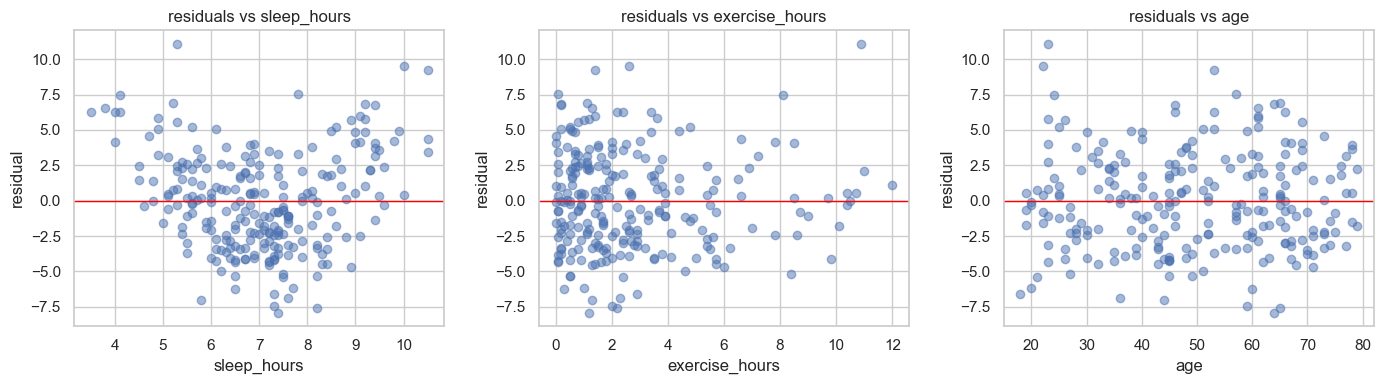

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, var in zip(axes, ["sleep_hours", "exercise_hours", "age"]):
    ax.scatter(df[var], m4.resid, alpha=0.5)
    ax.axhline(0, color="red", lw=1)
    ax.set_xlabel(var); ax.set_ylabel("residual")
    ax.set_title(f"residuals vs {var}")
plt.tight_layout()

The residuals vs `sleep_hours` show a clear **U-shaped pattern** — systematic structure the linear term missed. Residuals vs `exercise_hours` show a milder bend (over-predicting at low exercise). Both call for non-linear terms.

## 5. Basic non-linear forms

Linear models are linear **in the parameters**, not necessarily in the predictors. We can transform predictors and still use ordinary least squares.

### 5a. Quadratic term (U-shapes)

$$\text{phq9} = \dots + \beta_2\,\text{sleep} + \beta_{2q}\,\text{sleep}^2 + \dots$$

In a formula, `I(sleep_hours**2)` (the `I()` protects the arithmetic). The fitted parabola has its minimum at $-\beta_2 / (2\beta_{2q})$ — an estimate of the "optimal" amount of sleep.

### 5b. Logarithmic transform (diminishing returns)

$$\dots + \beta_3 \log(1+\text{exercise}) + \dots$$

Equal *multiplicative* increases in exercise give equal additive changes in PHQ-9: going 1→3 hours helps as much as 3→7. We use $\log(1+x)$ because some patients report 0 hours and $\log 0$ is undefined.

In [10]:
m5 = smf.ols("phq9 ~ age + sleep_hours + I(sleep_hours**2) + np.log1p(exercise_hours)"
             " + sex + C(treatment, Treatment(reference='none'))", data=df).fit()
print(m5.summary().tables[1])
print(f"R-squared: {m5.rsquared:.3f}   adj: {m5.rsquared_adj:.3f}")

b1 = m5.params["sleep_hours"]; b2 = m5.params["I(sleep_hours ** 2)"]
print(f"\nEstimated sleep duration minimizing expected PHQ-9: {-b1/(2*b2):.1f} hours")

                                                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                  49.6608      3.801     13.067      0.000      42.173      57.149
sex[T.Male]                                                -1.8301      0.375     -4.877      0.000      -2.569      -1.091
C(treatment, Treatment(reference='none'))[T.medication]    -3.0584      0.454     -6.739      0.000      -3.953      -2.164
C(treatment, Treatment(reference='none'))[T.therapy]       -2.7153      0.454     -5.982      0.000      -3.610      -1.821
age                                                        -0.0352      0.011     -3.176      0.002      -0.057      -0.013
sleep_hours                                               -10.8677      1.055    -10.303      0.000     -12.946      -8.789
I(sleep_

The fit improves markedly, and the estimated optimum is close to the 7–8 h clinicians would expect. Let's visualize the two non-linear partial effects — the model's prediction as one predictor varies with the others held at reference values.

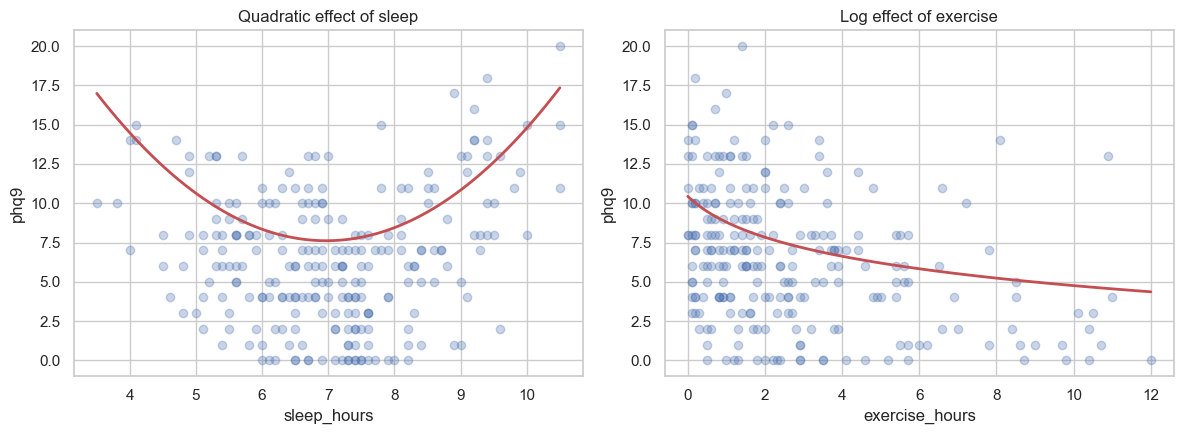

In [11]:
ref = dict(age=45, sleep_hours=7.5, exercise_hours=2.0, sex="Female", treatment="none")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sg = np.linspace(3.5, 10.5, 100)
pred = pd.DataFrame([ref]*100); pred["sleep_hours"] = sg
axes[0].scatter(df.sleep_hours, df.phq9, alpha=0.3)
axes[0].plot(sg, m5.predict(pred), "r-", lw=2)
axes[0].set(xlabel="sleep_hours", ylabel="phq9", title="Quadratic effect of sleep")

eg = np.linspace(0, 12, 100)
pred = pd.DataFrame([ref]*100); pred["exercise_hours"] = eg
axes[1].scatter(df.exercise_hours, df.phq9, alpha=0.3)
axes[1].plot(eg, m5.predict(pred), "r-", lw=2)
axes[1].set(xlabel="exercise_hours", ylabel="phq9", title="Log effect of exercise")
plt.tight_layout()

*(Curves are drawn for a 45-year-old untreated female; with no interaction terms, changing those settings only shifts each curve up or down — its shape is identical for everyone.)*

## 6. Model comparison

In [12]:
comparison = pd.DataFrame({
    "model": ["1: exercise only", "4: all linear", "5: quadratic + log"],
    "R2": [m1.rsquared, m4.rsquared, m5.rsquared],
    "adj_R2": [m1.rsquared_adj, m4.rsquared_adj, m5.rsquared_adj],
    "AIC": [m1.aic, m4.aic, m5.aic],
}).round(3)
comparison

,model,R2,adj_R2,AIC
0,1: exercise only,0.110,0.106,1348.987
1,4: all linear,0.324,0.307,1292.795
2,5: quadratic + log,0.550,0.536,1197.426


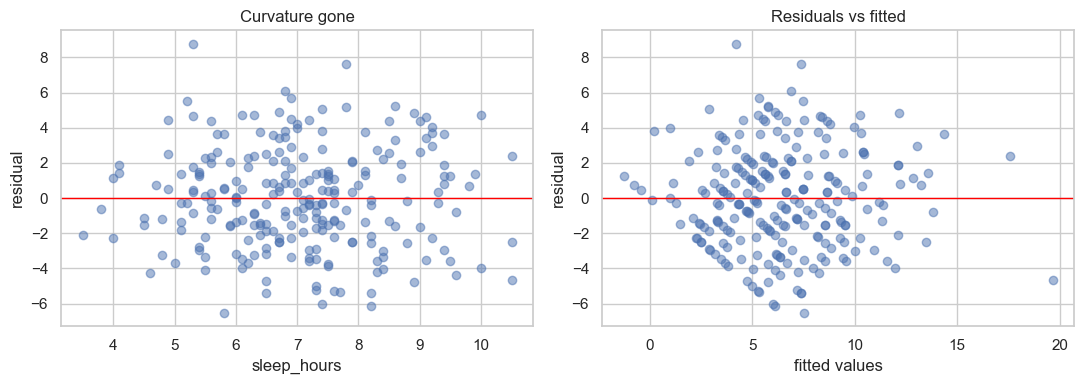

In [13]:
# Final check: residuals of the improved model
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(df.sleep_hours, m5.resid, alpha=0.5); axes[0].axhline(0, color="red", lw=1)
axes[0].set(xlabel="sleep_hours", ylabel="residual", title="Curvature gone")
axes[1].scatter(m5.fittedvalues, m5.resid, alpha=0.5); axes[1].axhline(0, color="red", lw=1)
axes[1].set(xlabel="fitted values", ylabel="residual", title="Residuals vs fitted")
plt.tight_layout()

## 7. Interpreting the final model, coefficient by coefficient

Model 5 is our final model. Let's read every estimate the way we would report it to a clinical audience. First, a tidy table:

In [14]:
summary = pd.DataFrame({
    "estimate": m5.params,
    "CI low": m5.conf_int()[0],
    "CI high": m5.conf_int()[1],
    "p-value": m5.pvalues,
}).round(3)
summary

,estimate,CI low,CI high,p-value
Intercept,49.661,42.173,57.149,0.000
sex[T.Male],-1.830,-2.569,-1.091,0.000
"C(treatment, Treatment(reference='none'))[T.medication]",-3.058,-3.953,-2.164,0.000
"C(treatment, Treatment(reference='none'))[T.therapy]",-2.715,-3.610,-1.821,0.000
age,-0.035,-0.057,-0.013,0.002
sleep_hours,-10.868,-12.946,-8.789,0.000
I(sleep_hours ** 2),0.780,0.635,0.925,0.000
np.log1p(exercise_hours),-2.369,-2.940,-1.799,0.000


### Intercept — a warning, not a finding

The intercept (~50) is the predicted PHQ-9 for a patient with `age = 0`, `sleep_hours = 0`, `exercise_hours = 0`, in both reference categories (female, untreated). No such patient exists — this is extrapolation far outside the data, and the "prediction" even exceeds the maximum possible score of 27. The intercept here is just a mathematical anchor for the fitted surface. *(Centering predictors, e.g. `I(age - 45)` and `I(sleep_hours - 7)`, would make it a meaningful "typical patient" prediction.)*

### `age` — statistically significant, clinically negligible

Holding everything else fixed, each additional year of age is associated with a ~0.04-point *lower* PHQ-9. Per **decade**, that is only ≈ 0.4 points — statistically significant (the CI excludes 0) yet far below ~5 points, a common benchmark for a clinically meaningful PHQ-9 change. **Statistical significance is a claim about evidence, not about magnitude.**

### `sleep_hours` and `sleep_hours²` — interpret jointly, never separately

The linear coefficient (≈ −10.9) does **not** mean "an hour of sleep lowers PHQ-9 by 11 points." With a quadratic term, the two coefficients only make sense together, as one curve:

$$\Delta(\text{sleep}) = \beta_2\,\text{sleep} + \beta_{2q}\,\text{sleep}^2$$

The curve bottoms out at $-\beta_2/(2\beta_{2q}) \approx 7$ h. Because the curve's slope changes along its range, "the effect of one more hour of sleep" depends on where you start — let's compute a few contrasts:

In [15]:
b1, b2 = m5.params["sleep_hours"], m5.params["I(sleep_hours ** 2)"]
effect = lambda s: b1*s + b2*s**2
for lo, hi in [(4, 5), (5, 6), (6, 7), (7, 8), (8, 9)]:
    print(f"sleeping {hi} h instead of {lo} h: {effect(hi)-effect(lo):+.1f} points")

sleeping 5 h instead of 4 h: -3.8 points
sleeping 6 h instead of 5 h: -2.3 points
sleeping 7 h instead of 6 h: -0.7 points
sleeping 8 h instead of 7 h: +0.8 points
sleeping 9 h instead of 8 h: +2.4 points


Extra sleep helps a lot when you are sleep-deprived, does almost nothing near 7 h, and is associated with *higher* scores beyond it — one curve, opposite slopes at its two ends.

### `np.log1p(exercise_hours)` — equal ratios, equal effects

The coefficient (≈ −2.4) is the change in expected PHQ-9 per one-unit increase in $\log(1+\text{exercise})$. Log-units are not intuitive, so translate to concrete contrasts: going from 0 → 3 h/week and from 3 → 7 h/week each double $(1+x)$ twice... more simply, compute:

In [16]:
b_ex = m5.params["np.log1p(exercise_hours)"]
for lo, hi in [(0, 1), (1, 3), (3, 7), (7, 12)]:
    print(f"exercising {hi} h instead of {lo} h: {b_ex*(np.log1p(hi)-np.log1p(lo)):+.1f} points")

exercising 1 h instead of 0 h: -1.6 points
exercising 3 h instead of 1 h: -1.6 points
exercising 7 h instead of 3 h: -1.6 points
exercising 12 h instead of 7 h: -1.2 points


The first hours of exercise carry most of the association — diminishing returns, exactly what the transform encodes.

### `sex[T.Male]` — a parallel shift

Males score on average ≈ 1.8 points *lower* than females **of the same age, sleep, exercise, and treatment**. With no interaction terms this difference is assumed constant everywhere — it shifts the whole regression surface down without changing its shape. Note this is an adjusted difference; it need not match the raw male–female gap from Section 3, because the groups may differ in the other predictors.

### `treatment` — the coefficients we may read causally

Compared with untreated patients, therapy is associated with ≈ 2.7 and medication with ≈ 3.1 points lower PHQ-9, other predictors held fixed. Because treatment was **randomized**, these are unbiased estimates of average treatment effects — and at half a severity band, clinically meaningful. Two cautions:

- The medication and therapy estimates differ by only ≈ 0.3 points, tiny relative to their confidence intervals. This model provides **no evidence that one treatment outperforms the other** — each is only compared against *no treatment*.
- These are *average* effects. Nothing in a no-interaction model tells us whether medication works better for some patients than others.

### Putting it together for one patient

In [17]:
patient = pd.DataFrame([dict(age=30, sleep_hours=5.0, exercise_hours=1.0,
                             sex="Male", treatment="medication")])
pred = m5.get_prediction(patient).summary_frame(alpha=0.05)
print(pred[["mean", "obs_ci_lower", "obs_ci_upper"]].round(1).to_string(index=False))

 mean  obs_ci_lower  obs_ci_upper
  7.2           1.4          13.0


A 30-year-old man on medication, sleeping 5 h and exercising 1 h/week: the point prediction sits in one severity band, but the 95% *prediction* interval for an individual spans several. **Models are far better at estimating averages than at predicting individuals** — a crucial distinction when tempted to use a regression as a clinical decision tool.

## 8. Caveats — the honest clinician's checklist

1. **Ordinal, bounded response.** PHQ-9 is a 0–27 integer score. The linear model can predict impossible values (negative, or >27). More advanced options: ordinal regression, or modelling item responses directly.
2. **Association ≠ causation.** Only `treatment` was randomized. The sleep and exercise coefficients are *associations*: patients who feel worse may exercise less and sleep worse *because* they are depressed (reverse causation).
3. **No interactions — by assumption.** We imposed identical effects across subgroups. Whether medication works equally well for all ages is exactly the kind of question an interaction term would address (next course topic!).
4. **Simulated data.** Real effect sizes and noise levels will differ; the true model here was known and conveniently additive.